In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib

# Reload modules to pick up changes
if "helper" in sys.modules:
    importlib.reload(sys.modules["helper"])
if "plotting" in sys.modules:
    importlib.reload(sys.modules["plotting"])

# import helper
# import plotting

import os
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

# import plotting
import importlib
# importlib.reload(plotting)
from pathlib import Path

import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


# Background Medium and Parameters

In [2]:
f_central  = 1.5 * 1e9 # 1.5 GHz
c = 3 * 1e8 # speed of light in m/s

# background properties
permittivity_ice      = 6
permittivity_air      = 1
# permittivity_fracture = 80 # water
permittivity_fracture = 6

conductivity_ice      = 1e-6
conductivity_air      = 0 
# conductivity_fracture = 0.05 # water
conductivity_fracture = 1e-6

In [3]:
c_ice   = c / np.sqrt(permittivity_ice)
c_air   = c / np.sqrt(permittivity_air)
c_water = c / np.sqrt(permittivity_fracture)
c_fracture = c / np.sqrt(permittivity_fracture)

wavelength_ice   = c_ice   / f_central
wavelength_air   = c_air   / f_central
wavelength_water = c_water / f_central
wavelength_fracture = c_fracture / f_central


thickness_fracture = wavelength_fracture / 10 # 1/10 of thinnest wavelength

# Define Experiment

In [4]:
permittivity_fracture_plus  = permittivity_fracture * 1.0
permittivity_fracture_minus = permittivity_fracture * 1.0

conductivity_fracture_plus  = conductivity_fracture * 1.2
conductivity_fracture_minus = conductivity_fracture * 0.8

In [5]:
# Block sizes given as fractions of the fracture wavelength
block_size_fractions = np.array([1/2, 1/4, 1/8])
block_sizes = block_size_fractions * wavelength_fracture

# Additional Parameters

In [6]:
# Determine the minimum grid spacing for the simulations
dx_min = min(wavelength_ice, wavelength_air, wavelength_water, wavelength_fracture, block_sizes.min()) / 10

source_receiver_steps = wavelength_fracture/10
# source_receiver_spacing = 0.10 # 10 cm

domain_width   = 12 * wavelength_fracture
fracture_depth = 0.3 # 3 * wavelength_ice rounded up to nearest 0.1 m
depth_below_fracture = 0.1
air_thickness  = 0.05

domain_height = air_thickness + fracture_depth + thickness_fracture + depth_below_fracture

number_of_blocks = (domain_width / block_sizes)

x_first_measurement = 1/2 * wavelength_fracture
x_last_measurement  = domain_width - 1/2 * wavelength_fracture

number_of_measurements = int((x_last_measurement - x_first_measurement) / source_receiver_steps) + 1


In [7]:
number_of_measurements

111

# Domain Extent and Block-Size Layout
Three domain views for the three block sizes. Each panel shows air, background, fracture layer, and alternating blocks.

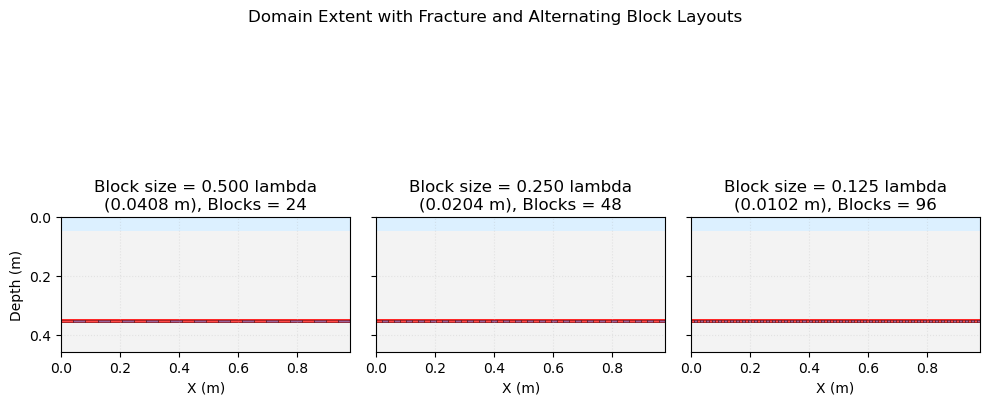

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

required_vars = [
    'domain_width', 'domain_height', 'air_thickness',
    'fracture_depth', 'thickness_fracture', 'block_sizes', 'wavelength_fracture'
    ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'Missing required variables: {missing}. Run the parameter cells first.')

fracture_top = air_thickness + fracture_depth
fracture_bottom = fracture_top + thickness_fracture

fig, axes = plt.subplots(1, len(block_sizes), figsize=(10, 5), sharey=True)
if len(block_sizes) == 1:
    axes = [axes]

for ax, bsize in zip(axes, block_sizes):
    n_blocks = int(np.round(domain_width / bsize))
    if n_blocks < 1:
        n_blocks = 1
    block_width = domain_width / n_blocks
    block_width_lambda = block_width / wavelength_fracture

    # Air and background regions
    ax.add_patch(Rectangle((0, 0), domain_width, air_thickness, facecolor='#d9efff', edgecolor='none', alpha=0.9, label='Air'))
    ax.add_patch(Rectangle((0, air_thickness), domain_width, domain_height - air_thickness, facecolor='#f3f3f3', edgecolor='none', alpha=1.0, label='Background'))

    # Fracture layer
    ax.add_patch(Rectangle((0, fracture_top), domain_width, thickness_fracture, facecolor='#ffd6d6', edgecolor='red', linewidth=1.2, label='Fracture'))

    # Alternating blocks in fracture
    for i in range(n_blocks):
        x0 = i * block_width
        color = '#ff6b6b' if i % 2 == 0 else '#4d96ff'
        ax.add_patch(Rectangle((x0, fracture_top), block_width, thickness_fracture, facecolor=color, edgecolor='black', linewidth=0.4, alpha=0.55))

    ax.set_title(f'Block size = {block_width_lambda:.3f} lambda\n({block_width:.4f} m), Blocks = {n_blocks}')
    ax.set_xlim(0, domain_width)
    ax.set_ylim(domain_height, 0)
    ax.set_xlabel('X (m)')
    ax.grid(alpha=0.25, linestyle=':')
    ax.set_aspect('equal', adjustable='box')

axes[0].set_ylabel('Depth (m)')
fig.suptitle('Domain Extent with Fracture and Alternating Block Layouts', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# # Create gprMax input files: one homogeneous (fractureless) + three block-scattering variants.
# required_vars = [
#     'f_central', 'c_ice', 'domain_width', 'domain_height', 'dx_min',
#     'air_thickness', 'fracture_depth', 'thickness_fracture', 'depth_below_fracture',
#     'block_size_fractions', 'wavelength_fracture',
#     'permittivity_ice', 'conductivity_ice',
#     'permittivity_air', 'conductivity_air',
#     'permittivity_fracture_plus', 'permittivity_fracture_minus',
#     'conductivity_fracture_plus', 'conductivity_fracture_minus',
#     'x_first_measurement', 'source_receiver_steps', 'number_of_measurements'
#     ]
# missing = [v for v in required_vars if v not in globals()]
# if missing:
#     raise ValueError(f'Missing required variables: {missing}. Run previous setup cells first.')

# dx_dy_dz = dx_min
TW = (1 / f_central) + (2 * (domain_height - (domain_height -  fracture_top)) / c_ice)  # seconds
snapshot_time = TW / 10
# n_snapshots = 10

# # Visual-depth coordinates (0 at top) for plotting-style definitions.
# fracture_top = air_thickness + fracture_depth
# fracture_bottom = fracture_top + thickness_fracture

# # Convert to gprMax y-coordinates (0 at bottom).
# y_air_bottom = domain_height - air_thickness
# y_frac_top_gpr = domain_height - fracture_top
# y_frac_bottom_gpr = domain_height - fracture_bottom
# y_frac_min = min(y_frac_top_gpr, y_frac_bottom_gpr)
# y_frac_max = max(y_frac_top_gpr, y_frac_bottom_gpr)

# # Source/receiver settings.
# tx_start_x = x_first_measurement
# tx_rx_offset = source_receiver_steps
# rx_start_x = tx_start_x + tx_rx_offset
# rx_y = y_air_bottom

# # Find the run index where source x is at half of the domain.
# x_mid = 0.5 * domain_width
# target_model_run = int(np.round((x_mid - tx_start_x) / source_receiver_steps)) + 1
# target_model_run = max(1, min(number_of_measurements, target_model_run))
# target_source_x = tx_start_x + (target_model_run - 1) * source_receiver_steps

# # 1) Homogeneous (fracture with constant properties) model.
# homogeneous_file = 'horizontal_scattering_homogeneous.in'
# with open(homogeneous_file, 'w') as f:
#     f.write('#title: Horizontal Scattering Homogeneous (Fractureless)')
#     f.write('\n#domain: {} {} {}'.format(domain_width, domain_height, dx_dy_dz))
#     f.write('\n#dx_dy_dz: {} {} {}'.format(dx_dy_dz, dx_dy_dz, dx_dy_dz))
#     f.write('\n#time_window: {}'.format(TW))

#     f.write('\n#material: {} {} 1 0 ice'.format(permittivity_ice, conductivity_ice))
#     f.write('\n#material: {} {} 1 0 air'.format(permittivity_air, conductivity_air))
#     f.write('\n#material: {} {} 1 0 constant_fracture'.format(permittivity_fracture, conductivity_fracture))

#     f.write('\n#waveform: ricker 1 {} my_ricker'.format(f_central))
#     f.write('\n#hertzian_dipole: z {} {} 0 my_ricker'.format(tx_start_x, rx_y))
#     f.write('\n#rx: {} {} 0'.format(rx_start_x, rx_y))
#     f.write('\n#src_steps: {} 0 0'.format(source_receiver_steps))
#     f.write('\n#rx_steps: {} 0 0'.format(source_receiver_steps))

#     # Air and background only (no fracture geometry).
#     f.write('\n#box: 0 {} 0 {} {} {} air'.format(y_air_bottom, domain_width, domain_height, dx_dy_dz))
#     f.write('\n#box: 0 0 0 {} {} {} ice'.format(domain_width, y_air_bottom, dx_dy_dz))

#     # Fracture geometry (constant properties).
#     f.write('\n#box: 0 {} 0 {} {} {} constant_fracture'.format(y_frac_min, domain_width, y_frac_max, dx_dy_dz))


#     # Multiple snapshots in time, only for the B-scan run where source x is at mid-domain.
#     f.write('\n#python:')
#     f.write('\nif current_model_run == {}:'.format(target_model_run))
#     f.write('\n    for i in range(1, {} + 1):'.format(n_snapshots))
#     f.write(
#         "\n        print('#snapshot: 0 0 0 {} {} {} {} {} {} {{}} snapshot_mid_x_{{}}'.format(i*{}, i))".format(
#             domain_width, domain_height, dx_dy_dz, dx_dy_dz, dx_dy_dz, dx_dy_dz, snapshot_time
#         )
#     )
#     f.write('\n#end_python:')

#     # Geometry view
#     f.write('\n#geometry_view: 0 0 0 {} {} {} {} {} {} horizontal_scattering_homogeneous n'.format(
#         domain_width, domain_height, dx_dy_dz, dx_dy_dz, dx_dy_dz, dx_dy_dz
#     ))

# print(
#     f"Created: {homogeneous_file} | snapshot run = {target_model_run}, source x = {target_source_x:.4f} m (target {x_mid:.4f} m) | "
#     f"snapshots = {n_snapshots}"
# )

# # 2) Scattering models (alternating fracture blocks).
# for frac in block_size_fractions:
#     block_size = frac * wavelength_fracture
#     n_blocks = int(np.round(domain_width / block_size))
#     if n_blocks < 1:
#         n_blocks = 1
#     if n_blocks % 2 != 0:
#         n_blocks += 1  # keep alternation balanced
#     block_width = domain_width / n_blocks

#     frac_tag = str(frac).replace('.', 'p')
#     out_file = f'horizontal_scattering_{frac_tag}lambda.in'

#     with open(out_file, 'w') as f:
#         f.write('#title: Horizontal Scattering Experiment')
#         f.write('\n#domain: {} {} {}'.format(domain_width, domain_height, dx_dy_dz))
#         f.write('\n#dx_dy_dz: {} {} {}'.format(dx_dy_dz, dx_dy_dz, dx_dy_dz))
#         f.write('\n#time_window: {}'.format(TW))

#         f.write('\n#material: {} {} 1 0 ice'.format(permittivity_ice, conductivity_ice))
#         f.write('\n#material: {} {} 1 0 air'.format(permittivity_air, conductivity_air))
#         f.write('\n#material: {} {} 1 0 fracture_plus'.format(permittivity_fracture_plus, conductivity_fracture_plus))
#         f.write('\n#material: {} {} 1 0 fracture_minus'.format(permittivity_fracture_minus, conductivity_fracture_minus))

#         f.write('\n#waveform: ricker 1 {} my_ricker'.format(f_central))
#         f.write('\n#hertzian_dipole: z {} {} 0 my_ricker'.format(tx_start_x, rx_y))
#         f.write('\n#rx: {} {} 0'.format(rx_start_x, rx_y))
#         f.write('\n#src_steps: {} 0 0'.format(source_receiver_steps))
#         f.write('\n#rx_steps: {} 0 0'.format(source_receiver_steps))

#         # Air and background
#         f.write('\n#box: 0 {} 0 {} {} {} air'.format(y_air_bottom, domain_width, domain_height, dx_dy_dz))
#         f.write('\n#box: 0 0 0 {} {} {} ice'.format(domain_width, y_air_bottom, dx_dy_dz))

#         # Alternating fracture blocks
#         for i in range(n_blocks):
#             x0 = i * block_width
#             x1 = (i + 1) * block_width if i < n_blocks - 1 else domain_width
#             mat = 'fracture_plus' if i % 2 == 0 else 'fracture_minus'
#             f.write('\n#box: {} {} 0 {} {} {} {}'.format(x0, y_frac_min, x1, y_frac_max, dx_dy_dz, mat))

#         # Multiple snapshots in time, only for the B-scan run where source x is at mid-domain.
#         f.write('\n#python:')
#         f.write('\nif current_model_run == {}:'.format(target_model_run))
#         f.write('\n    for i in range(1, {} + 1):'.format(n_snapshots))
#         f.write(
#             "\n        print('#snapshot: 0 0 0 {} {} {} {} {} {} {{}} snapshot_mid_x_{{}}'.format(i*{}, i))".format(
#                 domain_width, domain_height, dx_dy_dz, dx_dy_dz, dx_dy_dz, dx_dy_dz, snapshot_time
#             )
#         )
#         f.write('\n#end_python:')

#         # Geometry view
#         f.write('\n#geometry_view: 0 0 0 {} {} {} {} {} {} horizontal_scattering_{}lambda n'.format(domain_width, domain_height, dx_dy_dz, dx_dy_dz, dx_dy_dz, dx_dy_dz, frac_tag))

#     print(
#         f"Created: {out_file} | block size = {frac:.3f} lambda ({block_width:.4f} m), blocks = {n_blocks} | "
#         f"snapshot run = {target_model_run}, source x = {target_source_x:.4f} m (target {x_mid:.4f} m) | "
#         f"snapshots = {n_snapshots}"
#     )

# Generate Geometry

In [10]:
# horizontal_scattering_homogeneous = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_homogeneous.in'
# horizontal_scattering_0p_5lambda = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p5lambda.in'
# horizontal_scattering_0p_25lambda = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p25lambda.in'
# horizontal_scattering_0p_125lambda = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p125lambda.in'

# # Time-lapsed variants
# horizontal_scattering_0p_5lambda_timelapsed = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p5lambda_timelapsed_t1p0.in'
# horizontal_scattering_0p_25lambda_timelapsed = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p25lambda_timelapsed_t1p0.in'
# horizontal_scattering_0p_125lambda_timelapsed = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\horizontal_scattering_0p125lambda_timelapsed_t1p0.in'

# # Generate static geometries
# api(horizontal_scattering_homogeneous, n=1, geometry_only=True)
# api(horizontal_scattering_0p_5lambda, n=1, geometry_only=True)
# api(horizontal_scattering_0p_25lambda, n=1, geometry_only=True)
# api(horizontal_scattering_0p_125lambda, n=1, geometry_only=True)

# # Generate time-lapsed geometries
# api(horizontal_scattering_0p_5lambda_timelapsed, n=1, geometry_only=True)
# api(horizontal_scattering_0p_25lambda_timelapsed, n=1, geometry_only=True)
# api(horizontal_scattering_0p_125lambda_timelapsed, n=1, geometry_only=True)

# Visualise Full Wavefield

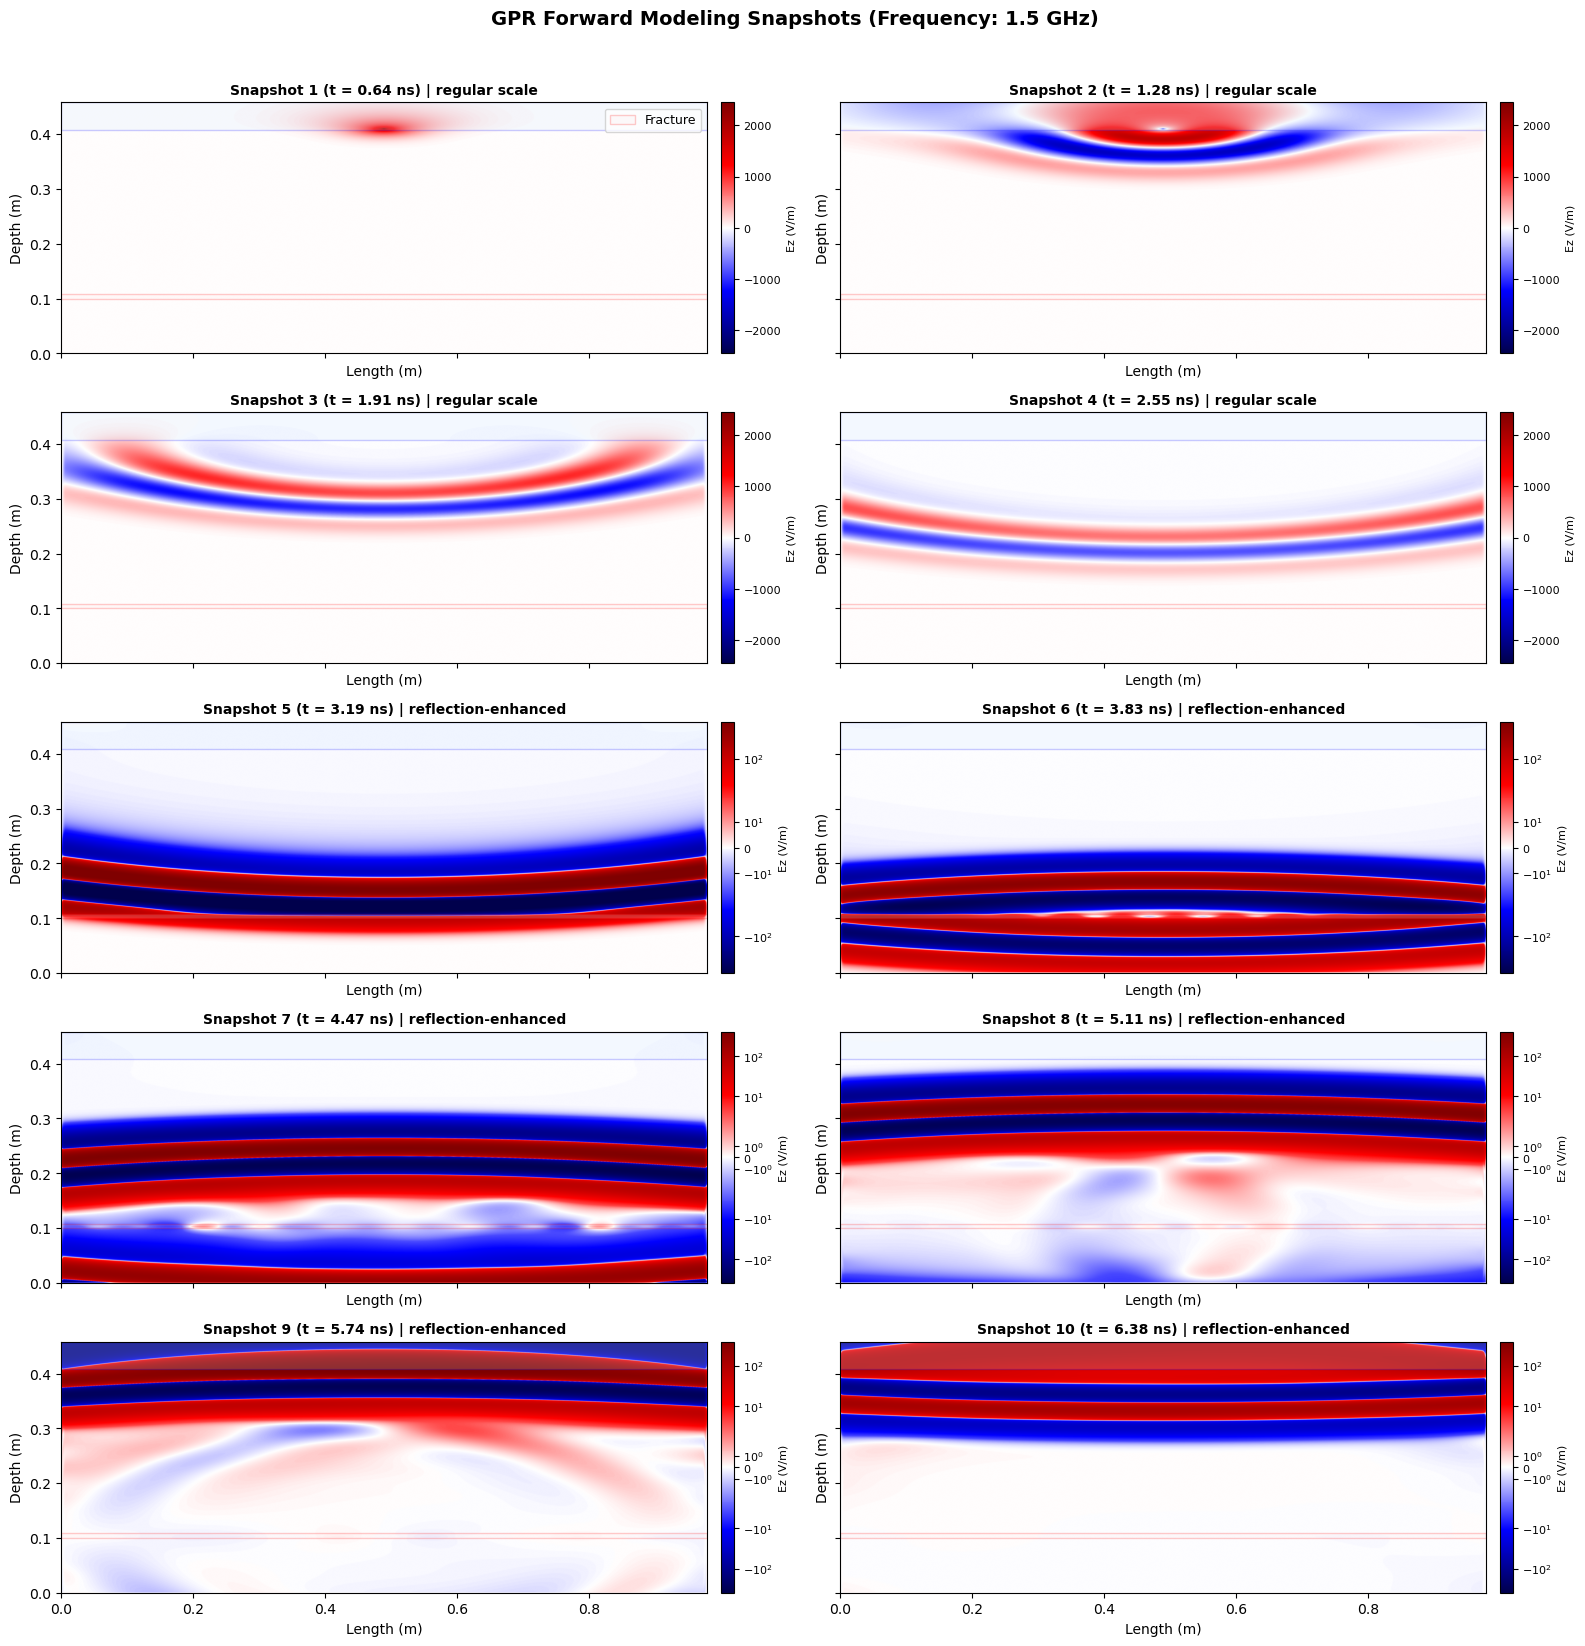

In [13]:
# Model dimensions
length = domain_width   # x-length (m)
depth  = domain_height   # y-depth (m)
upper_layer_thickness = air_thickness
fracture_y0 = domain_height - fracture_bottom
fracture_y1 = domain_height - fracture_top

# Path to snapshot folder and filename prefix
snapshot_folder = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\Horizontal_scattering_experiment\constant_permittivity\horizontal_scattering_0p5lambda_snaps56'
snapshot_prefix = 'snapshot_mid_x_'

# Select snapshots to plot
snapshot_indices = list(range(1, 11))

# Load all snapshots first so we can apply stage-wise color scales.
loaded_snapshots = []
for snap_num in snapshot_indices:
    snapshot_path = f'{snapshot_folder}\\{snapshot_prefix}{snap_num}.vti'
    mesh = pv.read(snapshot_path)
    dims = mesh.dimensions

    field_name = 'E-field'
    if field_name not in mesh.array_names:
        raise ValueError(f'Field {field_name} not found in {snapshot_path}. Available: {mesh.array_names}')

    data = mesh[field_name]
    if data.shape[1] == 3:
        Ez_data = data[:, 2]
    else:
        Ez_data = data.flatten()

    data_2d = Ez_data.reshape(dims[1] - 1, dims[0] - 1)
    loaded_snapshots.append((snap_num, data_2d))

# Three-stage scaling:
# 1-4 = regular, 5-6 = reflection-enhanced, 7-10 = reflection-enhanced (same method as 5-6).
early_data = [d for s, d in loaded_snapshots if s <= 4]
mid_data = [d for s, d in loaded_snapshots if 5 <= s <= 6]
late_data = [d for s, d in loaded_snapshots if s > 6]

early_abs_max = max(np.abs(d).max() for d in early_data)

# Use percentile limits for 5-10 to avoid a few strong outliers hiding weaker reflections.
mid_pct_ref = max(np.percentile(np.abs(d), 99.2) for d in mid_data)
late_pct_ref = max(np.percentile(np.abs(d), 99.7) for d in late_data)

# Make snapshots 5-6 noticeably tighter than 1-4.
mid_abs_max = min(mid_pct_ref, early_abs_max * 0.22)
mid_abs_max = max(mid_abs_max, early_abs_max * 0.035)

# Keep 7-10 reflection-enhanced but slightly less saturated than before.
late_abs_max = min(late_pct_ref, early_abs_max * 0.32)
late_abs_max = max(late_abs_max, early_abs_max * 0.06)

# Compact layout: 2 columns x 5 rows.
n_plots = len(snapshot_indices)
ncols = 2
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.3 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, (snap_num, data_2d) in enumerate(loaded_snapshots):
    ax = axes[i]

    if snap_num <= 4:
        vlim = early_abs_max
        scale_tag = 'regular scale'
        use_symlog = False
        symlog_linthresh_factor = 0.04
    elif snap_num <= 6:
        vlim = mid_abs_max
        scale_tag = 'reflection-enhanced'
        use_symlog = True
        symlog_linthresh_factor = 0.04
    else:
        vlim = late_abs_max
        scale_tag = 'reflection-enhanced'
        use_symlog = True
        symlog_linthresh_factor = 0.01

    if use_symlog:
        from matplotlib.colors import SymLogNorm
        im = ax.imshow(
            data_2d,
            aspect='auto',
            cmap='seismic',
            origin='lower',
            norm=SymLogNorm(linthresh=vlim * symlog_linthresh_factor, vmin=-vlim, vmax=vlim),
            extent=[0, length, 0, depth],
        )
    else:
        im = ax.imshow(
            data_2d,
            aspect='auto',
            cmap='seismic',
            origin='lower',
            vmin=-vlim,
            vmax=vlim,
            extent=[0, length, 0, depth],
        )

    time_ns = snap_num * snapshot_time * 1e9
    ax.set_title(f'Snapshot {snap_num} (t = {time_ns:.2f} ns) | {scale_tag}', fontsize=10, weight='bold')

    # Upper layer (top)
    ax.add_patch(
        Rectangle(
            (0, depth - upper_layer_thickness),
            length,
            upper_layer_thickness,
            facecolor='#cfe8ff',
            edgecolor='blue',
            alpha=0.2,
        )
    )

    # Fracture zone
    ax.add_patch(
        Rectangle(
            (0, fracture_y0),
            length,
            fracture_y1 - fracture_y0,
            facecolor='#ffe6e6',
            edgecolor='red',
            linewidth=1.0,
            alpha=0.2,
            label='Fracture' if i == 0 else '',
        )
    )

    ax.set_xlabel('Length (m)', fontsize=10)
    ax.set_ylabel('Depth (m)', fontsize=10)

    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

    # Separate colorbar per subfigure.
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label('Ez (V/m)', fontsize=8)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplot slots.
for j in range(n_plots, len(axes)):
    axes[j].axis('off')

fig.suptitle('GPR Forward Modeling Snapshots (Frequency: 1.5 GHz)', fontsize=14, weight='bold', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])

# # save image
# path = 'Images_Experiment_9\\Results\\Raw\\Snapshots_Process_1.png'
# plt.savefig(fname=path, bbox_inches='tight')

plt.show()

# Return A- and B-scan

In [ ]:
homogeneous_filename      = r'horizontal_scattering_homogeneous'
lambda_0p5_filename       = r'horizontal_scattering_0p5lambda'
lambda_0p25_filename      = r'horizontal_scattering_0p25lambda'
lambda_0p125_filename     = r'horizontal_scattering_0p125lambda'

# merge_files(homogeneous_filename, removefiles=True)
# merge_files(lambda_0p5_filename, removefiles=True)
# merge_files(lambda_0p25_filename, removefiles=True)
# merge_files(lambda_0p125_filename, removefiles=True)

# Resolve experiment directory robustly from likely notebook working directories.
candidates = [
    Path('.'),
    Path('Horizontal_scattering_experiment'),
    Path('True_and_Baseline_Models') / 'Horizontal_scattering_experiment',
]

exp_dir = None
for candidate in candidates:
    if candidate.exists() and any(candidate.glob('horizontal*.vti')):
        exp_dir = candidate
        break

if exp_dir is None:
    raise FileNotFoundError('Could not locate Horizontal_scattering_experiment directory with VTI files.')

# Keep only canonical geometry VTI files and remove numbered/extra variants.
keep_vti = {
    'horizontal_homogeneous.vti',
    'horizontal_scattering_0p5lambda.vti',
    'horizontal_scattering_0p25lambda.vti',
    'horizontal_scattering_0p125lambda.vti',
}

for file in exp_dir.glob('horizontal*.vti'):
    if file.name not in keep_vti:
        file.unlink()

print(f'Cleanup complete in: {exp_dir.resolve()}')

FileNotFoundError: Could not locate Horizontal_scattering_experiment directory with VTI files.

In [16]:
horizontal_homogeneous_data     = r'horizontal_scattering_homogeneous_merged.out'
horizontal_scattering_0p5_data  = r'horizontal_scattering_0p5lambda_merged.out'
horizontal_scattering_0p25_data = r'horizontal_scattering_0p25lambda_merged.out'
horizontal_scattering_0p125_data = r'horizontal_scattering_0p125lambda_merged.out'

rxnumber = 1
rxcomponent = 'Ez'

output_horizontal_homogeneous, dt = get_output_data(horizontal_homogeneous_data, rxnumber, rxcomponent)
output_horizontal_scattering_0p5, dt = get_output_data(horizontal_scattering_0p5_data, rxnumber, rxcomponent)
output_horizontal_scattering_0p25, dt = get_output_data(horizontal_scattering_0p25_data, rxnumber, rxcomponent)
output_horizontal_scattering_0p125, dt = get_output_data(horizontal_scattering_0p125_data, rxnumber, rxcomponent)

In [17]:
receiver_positions = np.arange(output_horizontal_homogeneous.shape[1]) * source_receiver_steps + x_first_measurement
time_axis = np.arange(output_horizontal_homogeneous.shape[0]) * dt

# extent = [x_min, x_max, t_max(ns), t_min(ns)]
extent = [receiver_positions[0], receiver_positions[-1], time_axis[-1] * 1e9, time_axis[0] * 1e9]

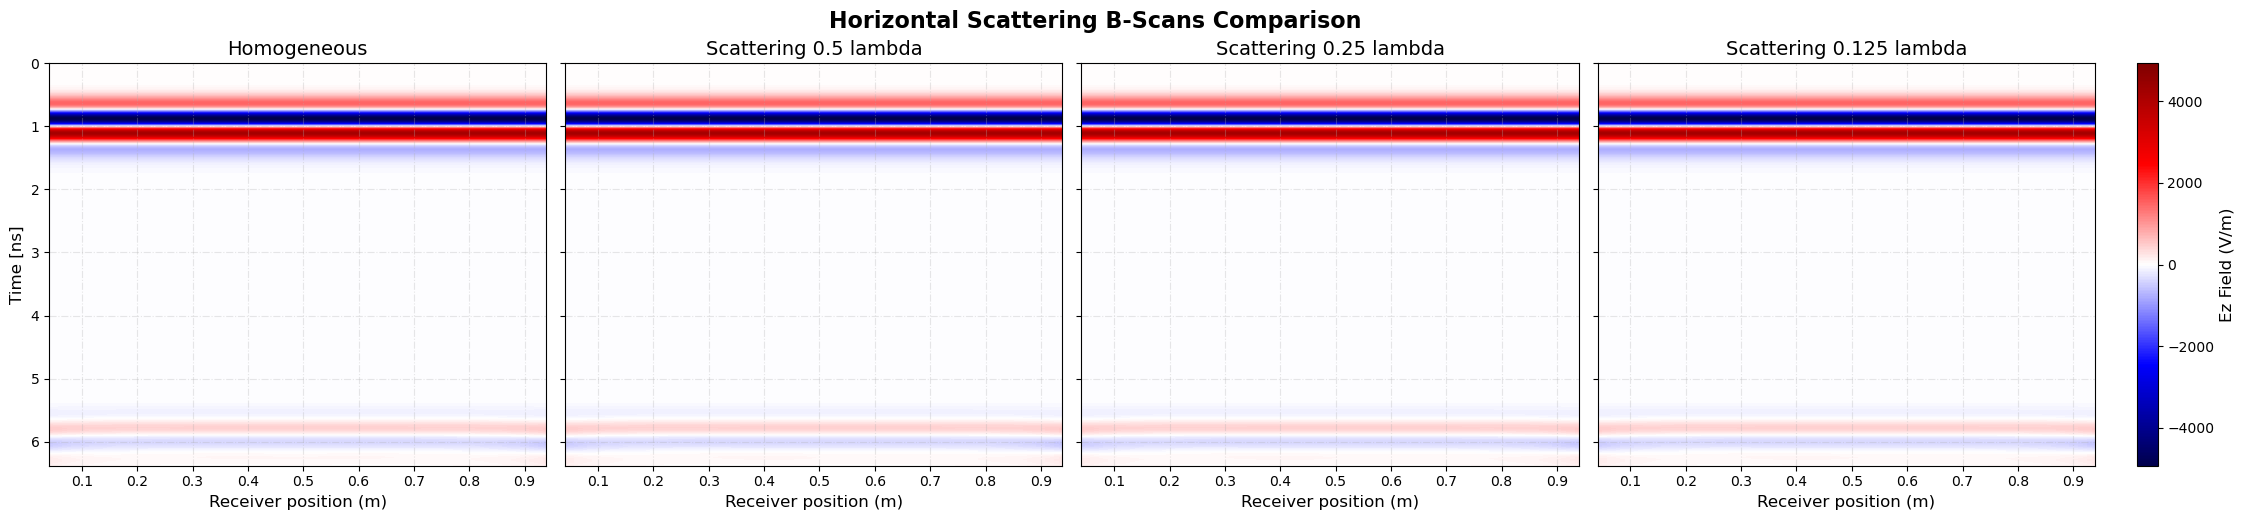

In [18]:
# Plot all horizontal-model B-scans side by side for comparison
fig, axes = plt.subplots(1, 4, figsize=(22, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)

data_all = [
    ('Homogeneous', output_horizontal_homogeneous),
    ('Scattering 0.5 lambda', output_horizontal_scattering_0p5),
    ('Scattering 0.25 lambda', output_horizontal_scattering_0p25),
    ('Scattering 0.125 lambda', output_horizontal_scattering_0p125),
]

# Use common color scaling across all plots
abs_max = max(np.abs(d).max() for _, d in data_all)
vmin = -abs_max
vmax = abs_max

for i, (title, data) in enumerate(data_all):
    ax = axes[i]
    im = ax.imshow(
        data,
        aspect='auto',
        cmap='seismic',
        extent=extent,
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Receiver position (m)', fontsize=12)
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=12)
    ax.grid(which='both', axis='both', linestyle='-.', alpha=0.3)

plt.tight_layout()

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Ez Field (V/m)', fontsize=12)

plt.suptitle('Horizontal Scattering B-Scans Comparison', fontsize=16, weight='bold', y=1.03)

# # save image
# out_dir = Path('Images_Experiment_9') / 'Results' / 'Raw'
# out_dir.mkdir(parents=True, exist_ok=True)
# path = out_dir / 'Horizontal_B-scans.png'
# plt.savefig(fname=path, bbox_inches='tight')

plt.show()

In [19]:
# Removing direct-wave
output_horizontal_scattering_0p5_no_direct   = output_horizontal_scattering_0p5 - output_horizontal_homogeneous
output_horizontal_scattering_0p25_no_direct  = output_horizontal_scattering_0p25 - output_horizontal_homogeneous
output_horizontal_scattering_0p125_no_direct = output_horizontal_scattering_0p125 - output_horizontal_homogeneous

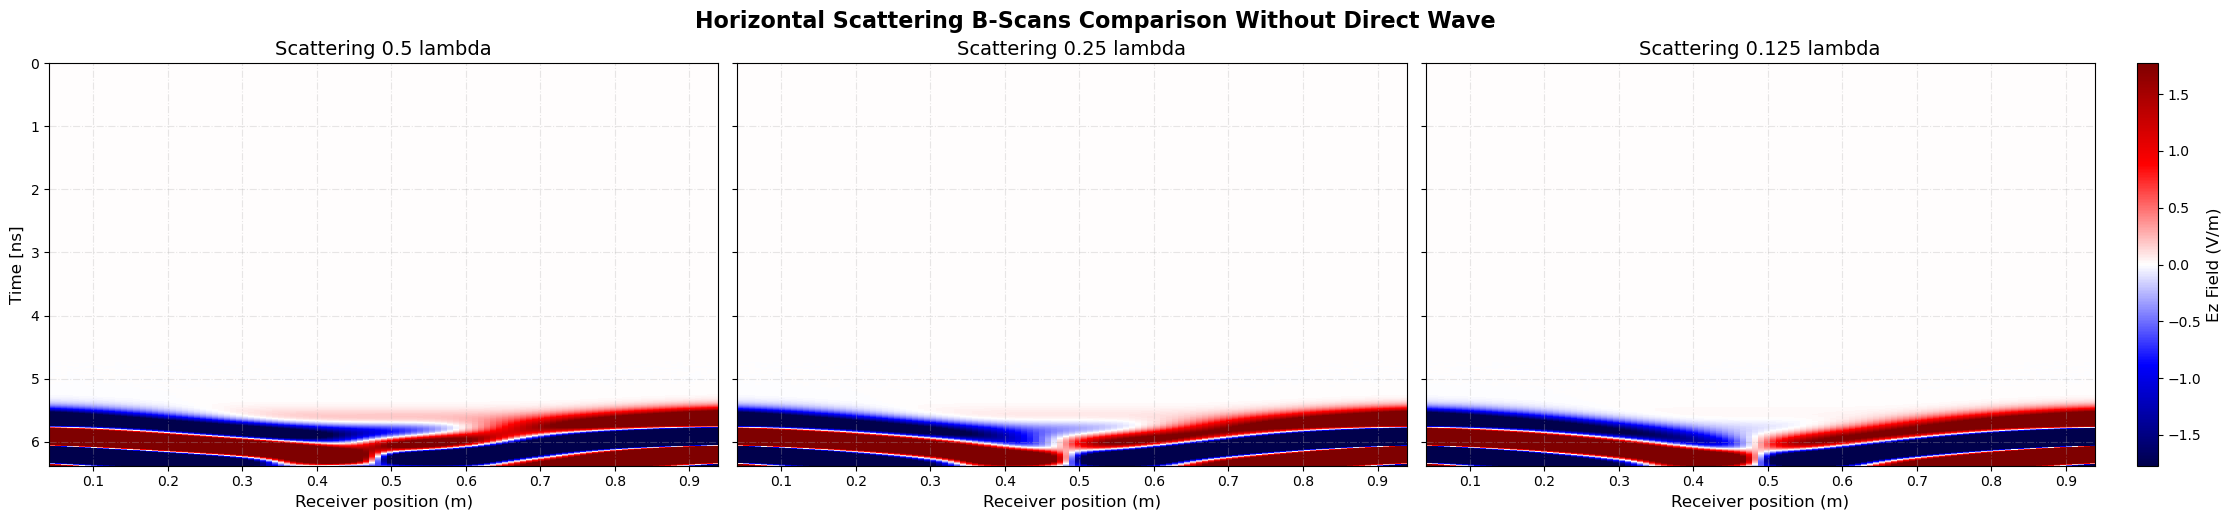

In [20]:
# Plot all horizontal-model B-scans side by side for comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)

data_all = [
    ('Scattering 0.5 lambda', output_horizontal_scattering_0p5_no_direct),
    ('Scattering 0.25 lambda', output_horizontal_scattering_0p25_no_direct),
    ('Scattering 0.125 lambda', output_horizontal_scattering_0p125_no_direct),
]

# Use common color scaling across all plots
abs_max = max(np.abs(d).max() for _, d in data_all)
vmin = -abs_max
vmax = abs_max

for i, (title, data) in enumerate(data_all):
    ax = axes[i]
    im = ax.imshow(
        data[:,:],
        aspect='auto',
        cmap='seismic',
        extent=extent,
        interpolation='nearest',
        vmin=1/10*vmin,
        vmax=1/10*vmax,
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Receiver position (m)', fontsize=12)
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=12)
    ax.grid(which='both', axis='both', linestyle='-.', alpha=0.3)

plt.tight_layout()

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Ez Field (V/m)', fontsize=12)

plt.suptitle('Horizontal Scattering B-Scans Comparison Without Direct Wave', fontsize=16, weight='bold', y=1.03)

# # save image
# out_dir = Path('Images_Experiment_9') / 'Results' / 'Raw'
# out_dir.mkdir(parents=True, exist_ok=True)
# path = out_dir / 'Horizontal_B-scans.png'
# plt.savefig(fname=path, bbox_inches='tight')

plt.show()

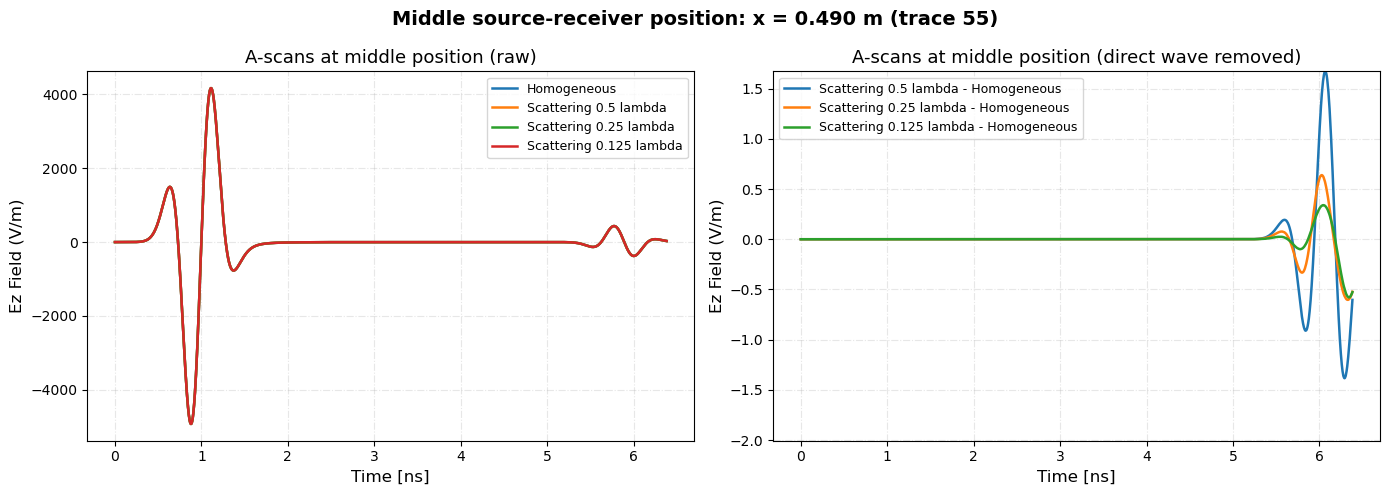

In [21]:
# Plot A-scans at the middle source-receiver position
mid_idx = output_horizontal_homogeneous.shape[1] // 2
mid_x = receiver_positions[mid_idx]
time_ns = time_axis * 1e9

ascans_raw = [
    ('Homogeneous', output_horizontal_homogeneous[:, mid_idx]),
    ('Scattering 0.5 lambda', output_horizontal_scattering_0p5[:, mid_idx]),
    ('Scattering 0.25 lambda', output_horizontal_scattering_0p25[:, mid_idx]),
    ('Scattering 0.125 lambda', output_horizontal_scattering_0p125[:, mid_idx]),
]

ascans_no_direct = [
    ('Scattering 0.5 lambda - Homogeneous', output_horizontal_scattering_0p5_no_direct[:, mid_idx]),
    ('Scattering 0.25 lambda - Homogeneous', output_horizontal_scattering_0p25_no_direct[:, mid_idx]),
    ('Scattering 0.125 lambda - Homogeneous', output_horizontal_scattering_0p125_no_direct[:, mid_idx]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, trace in ascans_raw:
    axes[0].plot(time_ns, trace, linewidth=1.8, label=label)
axes[0].set_title('A-scans at middle position (raw)', fontsize=13)
axes[0].set_xlabel('Time [ns]', fontsize=12)
axes[0].set_ylabel('Ez Field (V/m)', fontsize=12)
axes[0].grid(alpha=0.3, linestyle='-.')
axes[0].legend(fontsize=9)

for label, trace in ascans_no_direct:
    axes[1].plot(time_ns, trace, linewidth=1.8, label=label)
axes[1].set_title('A-scans at middle position (direct wave removed)', fontsize=13)
axes[1].set_xlabel('Time [ns]', fontsize=12)
axes[1].set_ylabel('Ez Field (V/m)', fontsize=12)
axes[1].grid(alpha=0.3, linestyle='-.')
axes[1].legend(fontsize=9)

# Use a tighter y-range for the direct-wave-removed panel.
no_direct_abs_max = max(np.abs(trace).max() for _, trace in ascans_no_direct)
axes[1].set_ylim(-1.2 * no_direct_abs_max, 1 * no_direct_abs_max)

fig.suptitle(f'Middle source-receiver position: x = {mid_x:.3f} m (trace {mid_idx})', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Cross Correlation

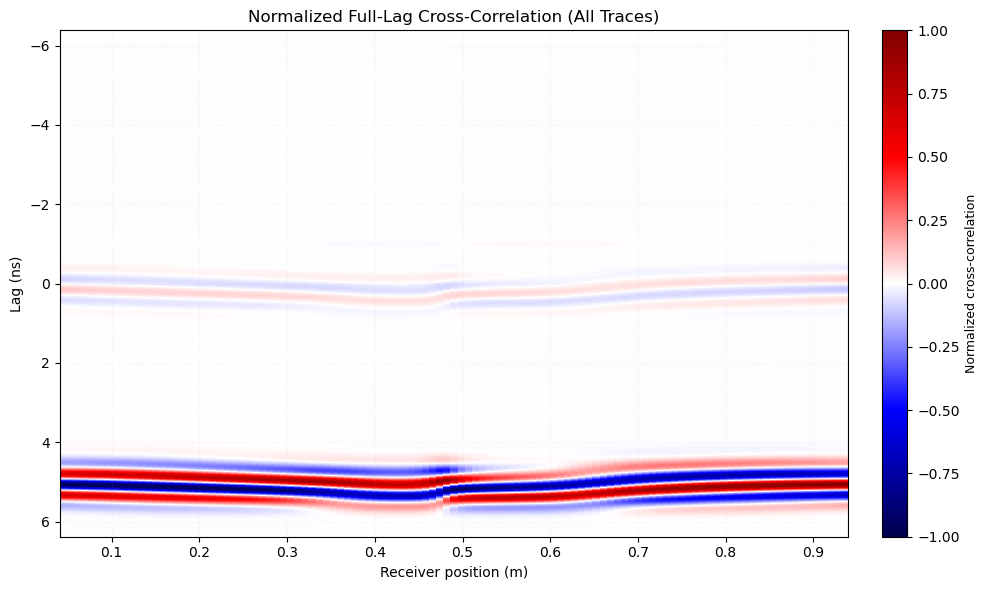

In [22]:
required_vars = ['output_horizontal_scattering_0p5_no_direct', 'output_horizontal_homogeneous', 'dt', 'receiver_positions']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'Missing required variables: {missing}. Run the previous data-loading cells first.')

A = np.asarray(output_horizontal_scattering_0p5_no_direct, dtype=float)
B = np.asarray(output_horizontal_homogeneous, dtype=float)

if A.shape != B.shape:
    raise ValueError(f'Shape mismatch: {A.shape} vs {B.shape}.')

n_samples, n_traces = A.shape
lags = np.arange(-n_samples + 1, n_samples)
lag_time_ns = lags * dt * 1e9

# Normalized full-lag cross-correlation for every trace.
all_xcorr = np.empty((len(lags), n_traces))
for i in range(n_traces):
    a = A[:, i] - A[:, i].mean()
    b = B[:, i] - B[:, i].mean()
    xcorr = np.correlate(a, b, mode='full')
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    all_xcorr[:, i] = xcorr / norm if norm > 0 else np.full_like(xcorr, np.nan, dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
extent_xcorr = [receiver_positions[0], receiver_positions[-1], lag_time_ns[-1], lag_time_ns[0]]
im = ax.imshow(
    all_xcorr,
    aspect='auto',
    cmap='seismic',
    extent=extent_xcorr,
    interpolation='nearest',
    vmin=-1,
    vmax=1,
)

ax.set_title('Normalized Full-Lag Cross-Correlation (All Traces)')
ax.set_xlabel('Receiver position (m)')
ax.set_ylabel('Lag (ns)')
ax.grid(alpha=0.15, linestyle=':')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized cross-correlation', fontsize=9)

plt.tight_layout()
plt.show()